# Notebook 04 — Evaluation & Results

## Projet : C-MARL pour la réduction des absences aux rendez-vous médicaux

Ce notebook sert à évaluer les trois checkpoints entraînés dans le Notebook 03 :

- `checkpoint_easy.pkl`
- `checkpoint_medium.pkl`
- `checkpoint_hard.pkl`

Objectif :

1. charger les datasets préparés ;
2. charger les modèles sauvegardés ;
3. évaluer les performances Easy / Medium / Hard ;
4. calculer le gain du stage Hard ;
5. créer les graphiques de comparaison ;
6. sauvegarder les résultats finaux.


## Cellule 1 — Imports

On importe les bibliothèques nécessaires pour charger les fichiers, évaluer les modèles et tracer les graphiques.


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Cellule 2 — Chemins du projet

Comme ce notebook est placé dans le dossier `notebooks`, on utilise `os.path.abspath("..")` pour revenir au dossier principal du projet.


In [2]:
PROJECT_PATH = os.path.abspath("..")

RESULTS_DIR = os.path.join(PROJECT_PATH, "results")
CHECKPOINT_DIR = os.path.join(PROJECT_PATH, "checkpoints")

EASY_DATA_PATH = os.path.join(RESULTS_DIR, "easy_data.csv")
MEDIUM_DATA_PATH = os.path.join(RESULTS_DIR, "medium_data.csv")
HARD_DATA_PATH = os.path.join(RESULTS_DIR, "hard_data.csv")

EASY_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_easy.pkl")
MEDIUM_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_medium.pkl")
HARD_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_hard.pkl")

print("Project path:", PROJECT_PATH)
print("Results dir:", RESULTS_DIR)
print("Checkpoint dir:", CHECKPOINT_DIR)

Project path: C:\Users\UltraPc\Documents\ML PROBA\C-marl
Results dir: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results
Checkpoint dir: C:\Users\UltraPc\Documents\ML PROBA\C-marl\checkpoints


## Cellule 3 — Vérification des fichiers

Avant l’évaluation, on vérifie que les datasets et les checkpoints existent.


In [3]:
required_files = [
    EASY_DATA_PATH,
    MEDIUM_DATA_PATH,
    HARD_DATA_PATH,
    EASY_CHECKPOINT_PATH,
    MEDIUM_CHECKPOINT_PATH,
    HARD_CHECKPOINT_PATH
]

for file_path in required_files:
    if os.path.exists(file_path):
        print("Trouvé:", file_path)
    else:
        print("Manquant:", file_path)

Trouvé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\easy_data.csv
Trouvé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\medium_data.csv
Trouvé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\hard_data.csv
Trouvé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\checkpoints\checkpoint_easy.pkl
Trouvé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\checkpoints\checkpoint_medium.pkl
Trouvé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\checkpoints\checkpoint_hard.pkl


## Cellule 4 — Chargement des datasets

On charge les trois datasets préparés dans le Notebook 01.


In [4]:
easy_data = pd.read_csv(EASY_DATA_PATH)
medium_data = pd.read_csv(MEDIUM_DATA_PATH)
hard_data = pd.read_csv(HARD_DATA_PATH)

print("Easy data:", easy_data.shape)
print("Medium data:", medium_data.shape)
print("Hard data:", hard_data.shape)

easy_data.head()

Easy data: (110521, 4)
Medium data: (110521, 10)
Hard data: (110521, 13)


,AgeGroup,Gender,SMS_received,No_show
0,3,0,0,0
1,2,1,0,0
2,3,0,0,0
3,0,0,0,0
4,2,0,0,0


## Cellule 5 — Définition de l’environnement RL

On reprend la même classe d’environnement que dans les notebooks précédents.

Chaque ligne représente un rendez-vous médical.  
L’environnement donne un état, reçoit une action, puis retourne une récompense.


In [5]:
class MedicalAppointmentEnv:
    def __init__(self, data, stage):
        self.data = data.reset_index(drop=True)
        self.stage = stage
        self.current_index = 0

        if stage == "easy":
            self.actions = [0, 1]
        elif stage == "medium":
            self.actions = [0, 1, 2]
        elif stage == "hard":
            self.actions = [0, 1, 2, 3]
        else:
            raise ValueError("stage must be: easy, medium, or hard")

        self.n_actions = len(self.actions)

    def reset(self):
        self.current_index = 0
        return self._get_state()

    def _get_state(self):
        if self.current_index >= len(self.data):
            return None

        patient = self.data.iloc[self.current_index]
        state = patient.drop("No_show").values
        return tuple(state.astype(int))

    def step(self, action):
        patient = self.data.iloc[self.current_index]
        reward = self._calculate_reward(patient, action)

        self.current_index += 1
        done = self.current_index >= len(self.data)
        next_state = None if done else self._get_state()

        return next_state, reward, done

    def _calculate_reward(self, patient, action):
        no_show = int(patient["No_show"])
        reward = 0

        if self.stage == "easy":
            if no_show == 1 and action == 1:
                reward += 2
            elif no_show == 1 and action == 0:
                reward -= 2
            elif no_show == 0 and action == 0:
                reward += 1
            elif no_show == 0 and action == 1:
                reward -= 0.5

        elif self.stage == "medium":
            medical_risk = int(patient["MedicalRisk"])

            if no_show == 1 and action == 1:
                reward += 3
            elif medical_risk == 1 and action == 2:
                reward += 2
            elif no_show == 1 and action == 0:
                reward -= 3
            elif no_show == 0 and action == 0:
                reward += 1
            else:
                reward -= 1

        elif self.stage == "hard":
            medical_risk = int(patient["MedicalRisk"])
            waiting_group = int(patient["WaitingGroup"])

            if no_show == 1 and action in [1, 3]:
                reward += 5
            elif no_show == 1 and action == 0:
                reward -= 5
            elif medical_risk == 1 and action == 2:
                reward += 3
            elif waiting_group >= 2 and action == 3:
                reward += 3
            elif no_show == 0 and action == 0:
                reward += 2
            else:
                reward -= 2

        return reward

    def get_action_space(self):
        return self.n_actions

    def get_number_of_patients(self):
        return len(self.data)

## Cellule 6 — Chargement des checkpoints

On charge les Q-tables sauvegardées dans le Notebook 03.

Une Q-table contient les valeurs apprises par l’agent pour choisir les meilleures actions selon les états.


## Cellule 6A — Définition de la classe QLearningAgent

Cette cellule est nécessaire pour relire correctement les checkpoints sauvegardés par `pickle`.

Dans le Notebook 03, les checkpoints peuvent contenir un objet `QLearningAgent`. Avant de charger un fichier `.pkl`, Python doit connaître cette classe.


In [6]:
class QLearningAgent:
    def __init__(self, n_actions, learning_rate=0.1, discount_factor=0.95,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.n_actions = n_actions
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = {}

    def get_q_values(self, state):
        if state not in self.q_table:
            self.q_table[state] = [0.0 for _ in range(self.n_actions)]
        return self.q_table[state]

    def choose_action(self, state):
        q_values = self.get_q_values(state)
        return int(max(range(self.n_actions), key=lambda action: q_values[action]))

    def update(self, state, action, reward, next_state, done):
        q_values = self.get_q_values(state)
        current_q = q_values[action]

        if done or next_state is None:
            target_q = reward
        else:
            next_q_values = self.get_q_values(next_state)
            target_q = reward + self.discount_factor * max(next_q_values)

        q_values[action] = current_q + self.learning_rate * (target_q - current_q)

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


In [7]:
def load_checkpoint(path):
    with open(path, "rb") as f:
        checkpoint = pickle.load(f)
    return checkpoint

checkpoint_easy = load_checkpoint(EASY_CHECKPOINT_PATH)
checkpoint_medium = load_checkpoint(MEDIUM_CHECKPOINT_PATH)
checkpoint_hard = load_checkpoint(HARD_CHECKPOINT_PATH)

print("Checkpoint Easy chargé.")
print("Checkpoint Medium chargé.")
print("Checkpoint Hard chargé.")

Checkpoint Easy chargé.
Checkpoint Medium chargé.
Checkpoint Hard chargé.


## Cellule 7 — Inspecter la structure des checkpoints

Selon la version du Notebook 03, un checkpoint peut être soit :

- directement une Q-table ;
- ou un dictionnaire contenant une Q-table.

Cette cellule identifie automatiquement la bonne structure.


In [8]:
def extract_q_table(checkpoint):
    """
    Extrait la vraie Q-table depuis plusieurs formats possibles de checkpoint.

    Formats acceptés :
    - {"q_table": ...}
    - {"Q": ...}
    - {"agent": QLearningAgent(...)}
    - QLearningAgent(...) directement
    - une Q-table directement sous forme de dictionnaire
    """

    if isinstance(checkpoint, dict):
        if "q_table" in checkpoint:
            return checkpoint["q_table"]

        if "Q" in checkpoint:
            return checkpoint["Q"]

        if "agent" in checkpoint:
            agent = checkpoint["agent"]
            if hasattr(agent, "q_table"):
                return agent.q_table
            raise ValueError("Le checkpoint contient un agent, mais cet agent ne contient pas q_table.")

        # Si le dictionnaire ressemble déjà à une Q-table : {state: q_values}
        return checkpoint

    if hasattr(checkpoint, "q_table"):
        return checkpoint.q_table

    raise ValueError("Format de checkpoint non reconnu.")


q_table_easy = extract_q_table(checkpoint_easy)
q_table_medium = extract_q_table(checkpoint_medium)
q_table_hard = extract_q_table(checkpoint_hard)

print("Type Q-table Easy:", type(q_table_easy))
print("Type Q-table Medium:", type(q_table_medium))
print("Type Q-table Hard:", type(q_table_hard))

print("Nombre d’états Easy:", len(q_table_easy))
print("Nombre d’états Medium:", len(q_table_medium))
print("Nombre d’états Hard:", len(q_table_hard))


Type Q-table Easy: <class 'dict'>
Type Q-table Medium: <class 'dict'>
Type Q-table Hard: <class 'dict'>
Nombre d’états Easy: 16
Nombre d’états Medium: 325
Nombre d’états Hard: 25343


## Cellule 8 — Fonction de sélection de l’action

Pendant l’évaluation, l’agent ne doit plus explorer au hasard.  
Il choisit l’action avec la meilleure valeur dans la Q-table.

Si un état est inconnu, on choisit l’action 0 par défaut : `ne rien faire`.


In [9]:
def choose_best_action(q_table_or_agent, state, n_actions):
    """
    Choisit l’action avec la valeur Q la plus élevée.

    La fonction accepte :
    - une Q-table directement ;
    - ou un objet agent contenant agent.q_table.
    """

    if hasattr(q_table_or_agent, "q_table"):
        q_table = q_table_or_agent.q_table
    else:
        q_table = q_table_or_agent

    if state in q_table:
        q_values = q_table[state]
        return int(np.argmax(q_values))

    # Si l’état n’existe pas dans la Q-table, on choisit l’action 0 par sécurité.
    return 0


## Cellule 9 — Fonction d’évaluation

Cette fonction évalue un agent sur tout le dataset.

Elle calcule :

- total reward ;
- average reward ;
- nombre de bonnes décisions ;
- nombre d’interventions ;
- nombre d’interventions inutiles ;
- taux de bonnes décisions.


In [10]:
def evaluate_agent(env, q_table):
    state = env.reset()
    done = False

    total_reward = 0
    total_steps = 0
    good_decisions = 0
    interventions = 0
    unnecessary_interventions = 0

    while not done:
        action = choose_best_action(q_table, state, env.get_action_space())

        current_patient = env.data.iloc[env.current_index]
        no_show = int(current_patient["No_show"])

        if action != 0:
            interventions += 1

        # Décision considérée comme correcte dans cette simulation :
        # - patient absent et action corrective
        # - patient présent et pas d’intervention
        if no_show == 1 and action != 0:
            good_decisions += 1
        elif no_show == 0 and action == 0:
            good_decisions += 1

        # Intervention inutile :
        # patient présent mais le système agit quand même
        if no_show == 0 and action != 0:
            unnecessary_interventions += 1

        next_state, reward, done = env.step(action)

        total_reward += reward
        total_steps += 1
        state = next_state

    average_reward = total_reward / total_steps if total_steps > 0 else 0
    good_decision_rate = good_decisions / total_steps if total_steps > 0 else 0
    intervention_rate = interventions / total_steps if total_steps > 0 else 0
    unnecessary_intervention_rate = unnecessary_interventions / total_steps if total_steps > 0 else 0

    return {
        "Total Reward": total_reward,
        "Average Reward": average_reward,
        "Total Steps": total_steps,
        "Good Decisions": good_decisions,
        "Good Decision Rate": good_decision_rate,
        "Interventions": interventions,
        "Intervention Rate": intervention_rate,
        "Unnecessary Interventions": unnecessary_interventions,
        "Unnecessary Intervention Rate": unnecessary_intervention_rate
    }

## Cellule 10 — Évaluation des trois stages

On crée un environnement pour chaque stage, puis on évalue la Q-table correspondante.


In [11]:
env_easy = MedicalAppointmentEnv(easy_data, "easy")
env_medium = MedicalAppointmentEnv(medium_data, "medium")
env_hard = MedicalAppointmentEnv(hard_data, "hard")

results_easy = evaluate_agent(env_easy, q_table_easy)
results_medium = evaluate_agent(env_medium, q_table_medium)
results_hard = evaluate_agent(env_hard, q_table_hard)

print("Résultats Easy:")
print(results_easy)

print("\nRésultats Medium:")
print(results_medium)

print("\nRésultats Hard:")
print(results_hard)

Résultats Easy:
{'Total Reward': 40048.5, 'Average Reward': 0.36236099926710763, 'Total Steps': 110521, 'Good Decisions': 72655, 'Good Decision Rate': 0.6573863790591833, 'Interventions': 31390, 'Intervention Rate': 0.28401842183838366, 'Unnecessary Interventions': 23471, 'Unnecessary Intervention Rate': 0.21236688050234798}

Résultats Medium:
{'Total Reward': 66699, 'Average Reward': 0.6034961681490395, 'Total Steps': 110521, 'Good Decisions': 59386, 'Good Decision Rate': 0.5373277476678641, 'Interventions': 51377, 'Intervention Rate': 0.46486188145239365, 'Unnecessary Interventions': 40099, 'Unnecessary Intervention Rate': 0.3628179260050126}

Résultats Hard:
{'Total Reward': 191580, 'Average Reward': 1.7334262266899503, 'Total Steps': 110521, 'Good Decisions': 74412, 'Good Decision Rate': 0.6732838103165915, 'Interventions': 45221, 'Intervention Rate': 0.4091620596990617, 'Unnecessary Interventions': 29508, 'Unnecessary Intervention Rate': 0.266989983803983}


## Cellule 11 — Tableau comparatif des résultats

On regroupe les résultats dans un tableau unique.


In [12]:
comparison_df = pd.DataFrame([
    {"Stage": "Easy", **results_easy},
    {"Stage": "Medium", **results_medium},
    {"Stage": "Hard", **results_hard}
])

comparison_df

,Stage,Total Reward,Average Reward,Total Steps,Good Decisions,Good Decision Rate,Interventions,Intervention Rate,Unnecessary Interventions,Unnecessary Intervention Rate
0,Easy,40048.5,0.362361,110521,72655,0.657386,31390,0.284018,23471,0.212367
1,Medium,66699.0,0.603496,110521,59386,0.537328,51377,0.464862,40099,0.362818
2,Hard,191580.0,1.733426,110521,74412,0.673284,45221,0.409162,29508,0.266990


## Cellule 12 — Calcul du gain Hard

L’objectif du projet précise : **gain Hard**.

Ici, on calcule le gain du stage Hard par rapport aux deux autres stages.


In [13]:
reward_easy = comparison_df.loc[comparison_df["Stage"] == "Easy", "Average Reward"].values[0]
reward_medium = comparison_df.loc[comparison_df["Stage"] == "Medium", "Average Reward"].values[0]
reward_hard = comparison_df.loc[comparison_df["Stage"] == "Hard", "Average Reward"].values[0]

gain_hard_vs_easy = reward_hard - reward_easy
gain_hard_vs_medium = reward_hard - reward_medium

gain_hard_vs_easy_percent = (gain_hard_vs_easy / abs(reward_easy)) * 100 if reward_easy != 0 else np.nan
gain_hard_vs_medium_percent = (gain_hard_vs_medium / abs(reward_medium)) * 100 if reward_medium != 0 else np.nan

print("Average Reward Easy:", reward_easy)
print("Average Reward Medium:", reward_medium)
print("Average Reward Hard:", reward_hard)

print("\nGain Hard vs Easy:", gain_hard_vs_easy)
print("Gain Hard vs Easy (%):", gain_hard_vs_easy_percent)

print("\nGain Hard vs Medium:", gain_hard_vs_medium)
print("Gain Hard vs Medium (%):", gain_hard_vs_medium_percent)

Average Reward Easy: 0.36236099926710763
Average Reward Medium: 0.6034961681490395
Average Reward Hard: 1.7334262266899503

Gain Hard vs Easy: 1.3710652274228425
Gain Hard vs Easy (%): 378.36997640361056

Gain Hard vs Medium: 1.1299300585409107
Gain Hard vs Medium (%): 187.23069311383978


## Cellule 13 — Ajouter le gain au tableau final

On ajoute deux colonnes pour faciliter l’interprétation :

- `Gain vs Easy`
- `Gain vs Medium`


In [14]:
comparison_df["Gain vs Easy"] = comparison_df["Average Reward"] - reward_easy
comparison_df["Gain vs Medium"] = comparison_df["Average Reward"] - reward_medium

comparison_df

,Stage,Total Reward,Average Reward,Total Steps,Good Decisions,Good Decision Rate,Interventions,Intervention Rate,Unnecessary Interventions,Unnecessary Intervention Rate,Gain vs Easy,Gain vs Medium
0,Easy,40048.5,0.362361,110521,72655,0.657386,31390,0.284018,23471,0.212367,0.000000,-0.241135
1,Medium,66699.0,0.603496,110521,59386,0.537328,51377,0.464862,40099,0.362818,0.241135,0.000000
2,Hard,191580.0,1.733426,110521,74412,0.673284,45221,0.409162,29508,0.266990,1.371065,1.129930


## Cellule 14 — Sauvegarder le tableau de résultats

Le tableau sera utilisé pour le rapport final et la présentation.


In [15]:
comparison_path = os.path.join(RESULTS_DIR, "evaluation_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print("Tableau sauvegardé dans:")
print(comparison_path)

Tableau sauvegardé dans:
C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\evaluation_comparison.csv


## Cellule 15 — Graphique 1 : Average Reward par stage

Ce graphique montre le niveau qui donne le meilleur gain moyen.


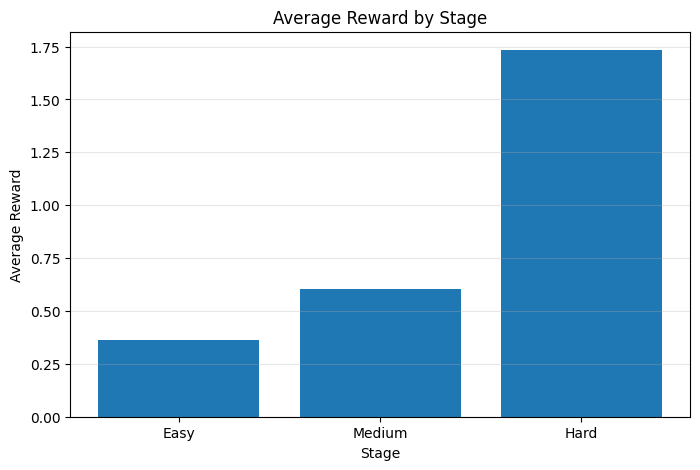

Graphique sauvegardé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\average_reward_by_stage.png


In [16]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Stage"], comparison_df["Average Reward"])
plt.title("Average Reward by Stage")
plt.xlabel("Stage")
plt.ylabel("Average Reward")
plt.grid(axis="y", alpha=0.3)

average_reward_plot_path = os.path.join(RESULTS_DIR, "average_reward_by_stage.png")
plt.savefig(average_reward_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé:", average_reward_plot_path)

## Cellule 16 — Graphique 2 : Taux de bonnes décisions

Ce graphique compare le pourcentage de décisions correctes pour Easy, Medium et Hard.


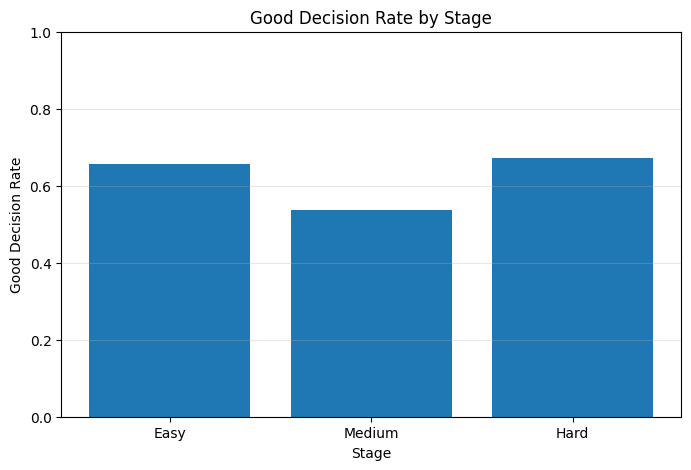

Graphique sauvegardé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\good_decision_rate_by_stage.png


In [17]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Stage"], comparison_df["Good Decision Rate"])
plt.title("Good Decision Rate by Stage")
plt.xlabel("Stage")
plt.ylabel("Good Decision Rate")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

good_decision_plot_path = os.path.join(RESULTS_DIR, "good_decision_rate_by_stage.png")
plt.savefig(good_decision_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé:", good_decision_plot_path)

## Cellule 17 — Graphique 3 : Interventions inutiles

Ce graphique montre le taux d’interventions inutiles.

Une intervention inutile signifie que le patient est venu, mais le système a quand même choisi une action corrective.


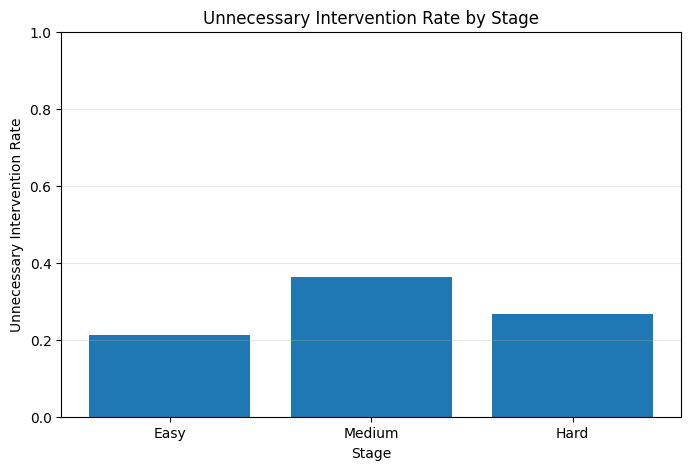

Graphique sauvegardé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\unnecessary_intervention_rate_by_stage.png


In [18]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Stage"], comparison_df["Unnecessary Intervention Rate"])
plt.title("Unnecessary Intervention Rate by Stage")
plt.xlabel("Stage")
plt.ylabel("Unnecessary Intervention Rate")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

unnecessary_plot_path = os.path.join(RESULTS_DIR, "unnecessary_intervention_rate_by_stage.png")
plt.savefig(unnecessary_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé:", unnecessary_plot_path)

## Cellule 18 — Interprétation automatique simple

Cette cellule donne une interprétation courte selon les résultats obtenus.


In [19]:
best_stage = comparison_df.loc[comparison_df["Average Reward"].idxmax(), "Stage"]

print("Meilleur stage selon Average Reward:", best_stage)

if best_stage == "Hard":
    print("Le stage Hard donne le meilleur gain. Cela respecte l'objectif du projet.")
else:
    print("Attention : le stage Hard ne donne pas le meilleur gain.")
    print("Dans ce cas, il faudra ajuster les récompenses, le nombre d'épisodes ou la stratégie d'entraînement.")

Meilleur stage selon Average Reward: Hard
Le stage Hard donne le meilleur gain. Cela respecte l'objectif du projet.


## Cellule 19 — Résumé final

On affiche un résumé propre pour le rapport.


In [20]:
summary_text = f'''
Résumé de l'évaluation C-MARL

Average Reward Easy   : {reward_easy:.4f}
Average Reward Medium : {reward_medium:.4f}
Average Reward Hard   : {reward_hard:.4f}

Gain Hard vs Easy     : {gain_hard_vs_easy:.4f}
Gain Hard vs Medium   : {gain_hard_vs_medium:.4f}

Meilleur stage        : {best_stage}
'''

print(summary_text)

summary_path = os.path.join(RESULTS_DIR, "evaluation_summary.txt")

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Résumé sauvegardé dans:", summary_path)


Résumé de l'évaluation C-MARL

Average Reward Easy   : 0.3624
Average Reward Medium : 0.6035
Average Reward Hard   : 1.7334

Gain Hard vs Easy     : 1.3711
Gain Hard vs Medium   : 1.1299

Meilleur stage        : Hard

Résumé sauvegardé dans: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\evaluation_summary.txt


## Cellule 20 — Fin du Notebook 04

À la fin de ce notebook, le dossier `results/` doit contenir :

- `evaluation_comparison.csv`
- `evaluation_summary.txt`
- `average_reward_by_stage.png`
- `good_decision_rate_by_stage.png`
- `unnecessary_intervention_rate_by_stage.png`

Ces fichiers seront utilisés dans le Notebook 05 pour préparer les figures et les éléments du rapport.
